<a href="https://colab.research.google.com/github/heyygauravai/bank-loan-approval-risk-predictor/blob/main/Loan_default_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Imports**

In [334]:

# 1. DATA HANDLING & VISUALIZATION

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 2. PREPROCESSING & IMBALANCE HANDLING

from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
# We use imblearn.pipeline, NOT sklearn.pipeline.
# This ensures SMOTE is applied ONLY to the training fold during CV.
from imblearn.pipeline import Pipeline as ImbPipeline


# 3. MACHINE LEARNING MODELS

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# 4. MODEL VALIDATION & TUNING

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
# 5. METRICS & EVALUATION

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    make_scorer,
    recall_score,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
)
recall_scorer = make_scorer(recall_score, pos_label=0)

# 6. PROBABILITY CALIBRATION

from sklearn.calibration import CalibratedClassifierCV


# 7. GLOBAL CONFIGURATIONS (The Constants)

# RANDOM_STATE: Ensures every split, SMOTE generation, and model
# initialization is 100% reproducible. If you run the notebook
# again, you get the exact same numbers.
RANDOM_STATE = 42

# TEST_SIZE: 20% is the industry standard for small-to-medium
# datasets (614 rows). It gives enough data to train on while
# keeping a decent chunk for validation.
TEST_SIZE = 0.2

# N_FOLDS: 5-fold Cross-Validation is the gold standard.
# It gives a stable estimate of performance without taking
# too long to compute.
N_FOLDS = 5


# **Loading the dataset**

In [335]:
# 1. Uploading the dataset in Google Colab
#    from Kaggle:- https://www.kaggle.com/datasets/altruistdelhite04/loan-prediction-problem-dataset

# 2. Loading the dataset using Pandas

df = pd.read_csv('/content/train_u6lujuX_CVtuZ9i.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# **Preprocessing**

In [336]:

# STEP 1: Dropping Loan_ID (not useful for prediction)

df.drop('Loan_ID', axis=1, inplace=True)
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


**Checking and fixing null values and outliers**

In [337]:
df.isnull().sum()

,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14
Credit_History,50


In [338]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             601 non-null    object 
 1   Married            611 non-null    object 
 2   Dependents         599 non-null    object 
 3   Education          614 non-null    object 
 4   Self_Employed      582 non-null    object 
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         592 non-null    float64
 8   Loan_Amount_Term   600 non-null    float64
 9   Credit_History     564 non-null    float64
 10  Property_Area      614 non-null    object 
 11  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 57.7+ KB


In [339]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [340]:

# STEP 2: Filling missing values

# For Categorical columns -> filling with mode (most frequent values)
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

# For Numerical columns -> filling with median (robust to outliers)
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].median())




In [341]:
df.isnull().sum()

,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0


**Encoding binary categoricals**

In [342]:
# STEP 3: Encoding binary categoricals

df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['Married'] = df['Married'].map({'Yes': 1, 'No': 0})
df['Self_Employed'] = df['Self_Employed'].map({'Yes': 1, 'No': 0})
df['Education'] = df['Education'].map({'Graduate': 1, 'Not Graduate': 0})
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,1,0,5849,0.0,128.0,360.0,1.0,Urban,Y
1,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,Rural,N
2,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,Urban,Y
3,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,Urban,Y


**Using one hot encoding**

In [343]:
# STEP 4: One-hot encoding multi-class columns

df = pd.get_dummies(df, columns=['Dependents', 'Property_Area'], drop_first=True, dtype=int)
df.head()

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Dependents_1,Dependents_2,Dependents_3+,Property_Area_Semiurban,Property_Area_Urban
0,1,0,1,0,5849,0.0,128.0,360.0,1.0,Y,0,0,0,0,1
1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,N,1,0,0,0,0
2,1,1,1,1,3000,0.0,66.0,360.0,1.0,Y,0,0,0,0,1
3,1,1,0,0,2583,2358.0,120.0,360.0,1.0,Y,0,0,0,0,1
4,1,0,1,0,6000,0.0,141.0,360.0,1.0,Y,0,0,0,0,1


**encoding target column**

In [344]:
# STEP 5: Encode target column

df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})
df.head()

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Dependents_1,Dependents_2,Dependents_3+,Property_Area_Semiurban,Property_Area_Urban
0,1,0,1,0,5849,0.0,128.0,360.0,1.0,1,0,0,0,0,1
1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,1,0,0,0,0
2,1,1,1,1,3000,0.0,66.0,360.0,1.0,1,0,0,0,0,1
3,1,1,0,0,2583,2358.0,120.0,360.0,1.0,1,0,0,0,0,1
4,1,0,1,0,6000,0.0,141.0,360.0,1.0,1,0,0,0,0,1


In [345]:
df

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Dependents_1,Dependents_2,Dependents_3+,Property_Area_Semiurban,Property_Area_Urban
0,1,0,1,0,5849,0.0,128.0,360.0,1.0,1,0,0,0,0,1
1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,1,0,0,0,0
2,1,1,1,1,3000,0.0,66.0,360.0,1.0,1,0,0,0,0,1
3,1,1,0,0,2583,2358.0,120.0,360.0,1.0,1,0,0,0,0,1
4,1,0,1,0,6000,0.0,141.0,360.0,1.0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,1,0,2900,0.0,71.0,360.0,1.0,1,0,0,0,0,0
610,1,1,1,0,4106,0.0,40.0,180.0,1.0,1,0,0,1,0,0
611,1,1,1,0,8072,240.0,253.0,360.0,1.0,1,1,0,0,0,1
612,1,1,1,0,7583,0.0,187.0,360.0,1.0,1,0,1,0,0,1


# **Data Preprocessing Summary**


**Identifier Removal:** Dropped the Loan_ID column as it is a unique identifier with no predictive value for the target variable.

**Missing Value Imputation:**

**Categorical Features:** Imputed missing values using the mode (most frequent value) to preserve the central tendency of the distribution.

**Numerical Features:** Imputed missing values using the median to ensure robustness against outliers (e.g., extreme income or loan amounts).

**Categorical Encoding:**

**Binary Features:** Mapped binary categories (e.g., Gender, Married) to 0/1 integers. This is mathematically equivalent to one-hot encoding with drop_first=True and does not introduce any false ordinal relationship.

**Nominal Features:** Applied One-Hot Encoding to multi-class categorical variables (Dependents, Property_Area) to prevent the model from incorrectly interpreting them as ordinal variables.

**Target Encoding:** Mapped the target variable Loan_Status from 'Y'/'N' to binary integers (1/0) for model training.

**Outcome:** A clean, fully numeric dataset with no missing values, ready for exploratory data analysis and model building.



# **EDA (Visualizations)**

In [346]:
# Setting a clean style for all plots
sns.set_style("whitegrid")

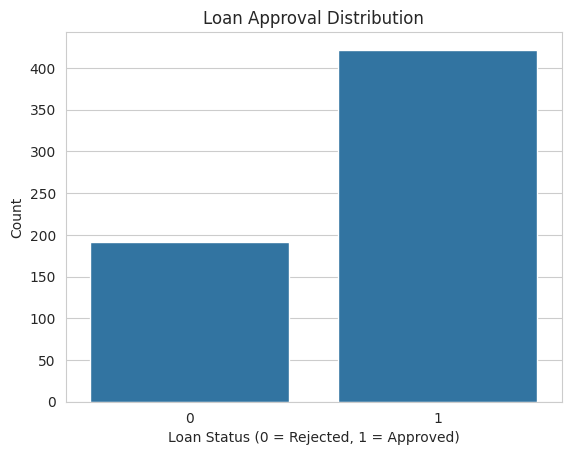

In [347]:
# PLOT 1: Target Variable Distribution
# Question: Is the data balanced?


sns.countplot(data=df, x='Loan_Status')
plt.title('Loan Approval Distribution')
plt.xlabel('Loan Status (0 = Rejected, 1 = Approved)')
plt.ylabel('Count')
plt.show()

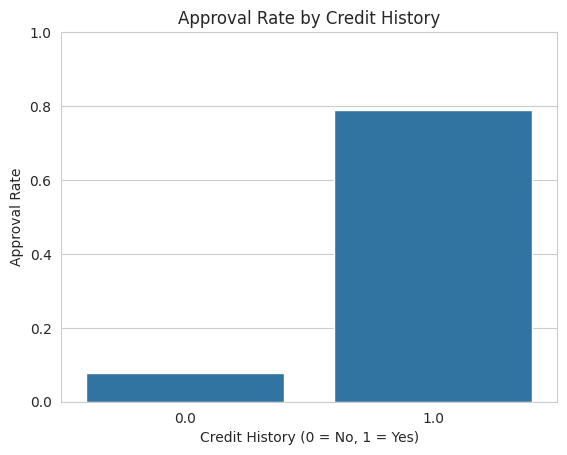

In [348]:
# PLOT 2: Credit History vs Approval Rate
# Question: How much does having a credit history affect approval?

credit_approval = df.groupby('Credit_History')['Loan_Status'].mean().reset_index()
sns.barplot(data=credit_approval, x='Credit_History', y='Loan_Status')
plt.title('Approval Rate by Credit History')
plt.xlabel('Credit History (0 = No, 1 = Yes)')
plt.ylabel('Approval Rate')
plt.ylim(0, 1)
plt.show()

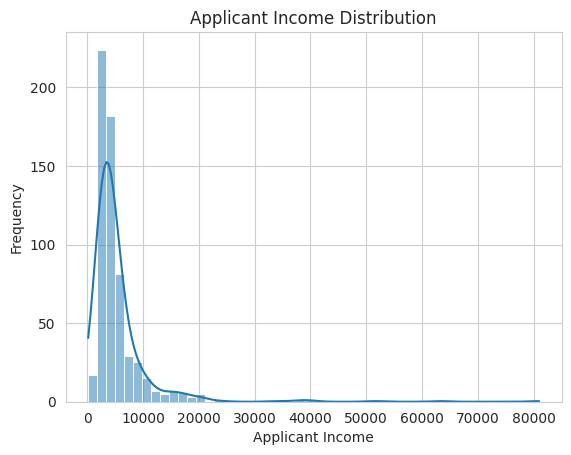

In [349]:
# PLOT 3: Applicant Income Distribution
# Question: Is income skewed? (Validates why we used Median for imputation)

sns.histplot(df['ApplicantIncome'], kde=True, bins=50)
plt.title('Applicant Income Distribution')
plt.xlabel('Applicant Income')
plt.ylabel('Frequency')
plt.show()

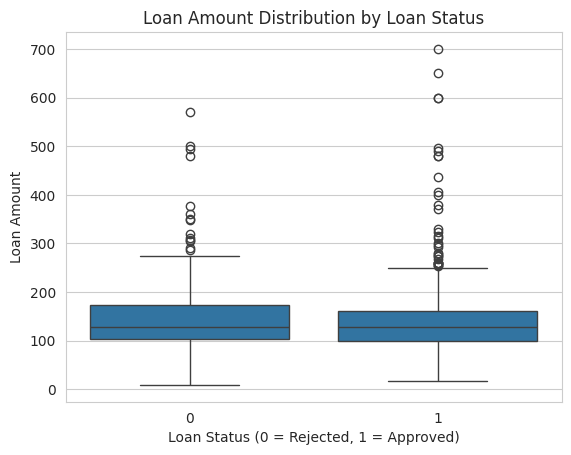

In [350]:
# PLOT 4: Loan Amount vs Loan Status
# Question: Do approved loans have higher/lower amounts?

sns.boxplot(data=df, x='Loan_Status', y='LoanAmount')
plt.title('Loan Amount Distribution by Loan Status')
plt.xlabel('Loan Status (0 = Rejected, 1 = Approved)')
plt.ylabel('Loan Amount')
plt.show()

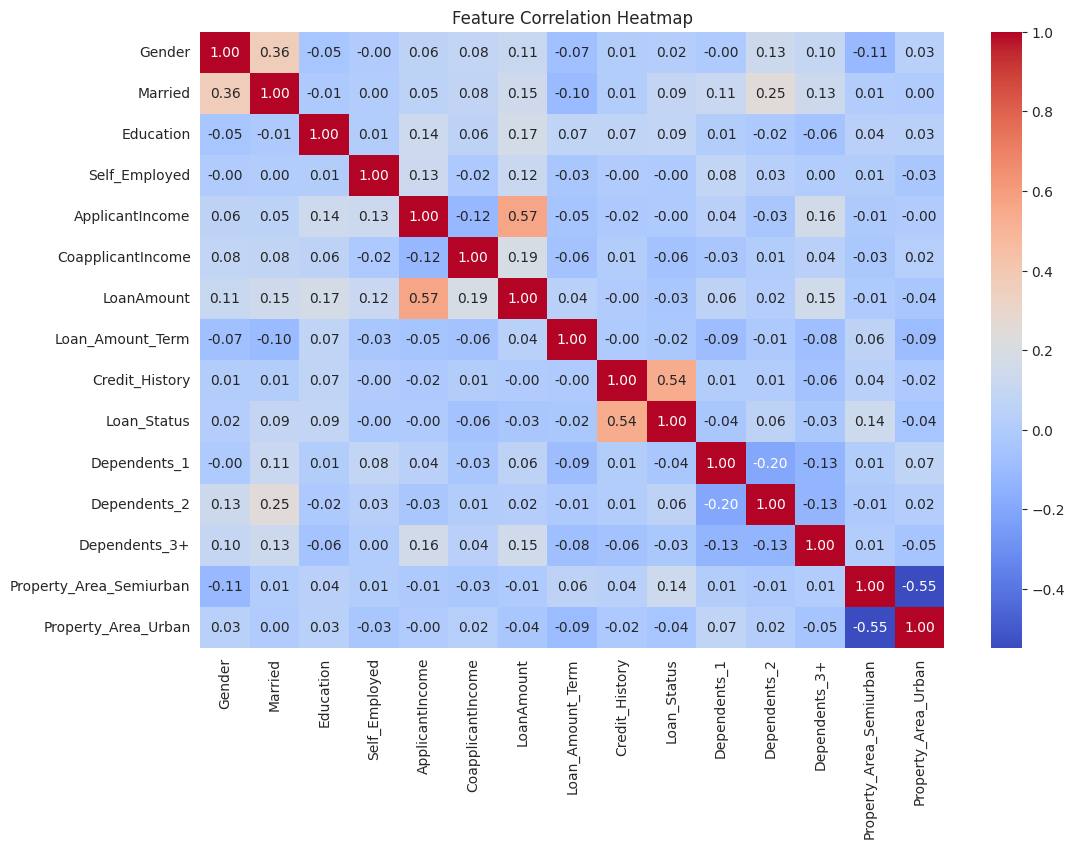

In [351]:
# PLOT 5: Correlation Heatmap
# Question: Which features are most correlated with Loan_Status?

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True,cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

# **EDA Summary**
**Target Imbalance:** The target variable (Loan_Status) is imbalanced, with approximately 70% Approved and 30% Rejected. This confirms that Accuracy is a misleading metric; we will prioritize Recall for the Rejected class and use SMOTE during modeling.

**The Dominant Feature:** Credit_History shows a massive impact. Approval rates are around 80% when present, but drop to ~8% when absent. This will likely be the most important predictor in our model.

**Skewed Distributions:** Features like ApplicantIncome and LoanAmount are heavily right-skewed. This validates our decision to use the Median for imputation and confirms the need for scaling (StandardScaler) before model training.

**Feature Relationships:** The correlation heatmap confirms Credit_History has the strongest positive correlation with Loan_Status. No significant multicollinearity (highly correlated features) was found, so we don't need to drop any redundant columns.

# **Spliting the data for training**


In [352]:
# 1. Separating features (X) and target (Y)
X = df.drop('Loan_Status', axis=1)
Y = df['Loan_Status']

# 2. Splitting into 80% train, 20% test
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=TEST_SIZE,
    random_state= RANDOM_STATE,
    stratify=Y  #Keeps the 70/30 ratio same in both sets
)


In [353]:
# Setting up 5-Fold Stratified Cross-Validation
# n_splits=5 -> 5 folds
# shuffle=True -> Shuffle data before splitting (to avoid any accidental ordering)
# random_state=42 -> So we get the exact same splits every time (reproducible)
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)


In [354]:
# Reusable function to compute Stratified K-Fold cross-validation recall
# for any pipeline. Used to compare Logistic Regression, XGBoost, and
# Random Forest fairly, using the same CV splits and the same metric
# (recall on the minority/Rejected class), instead of repeating this
# loop manually for each model

def get_cv_recall(pipeline, X_train, Y_train, cv, pos_label=0, model_name="Model"):
    fold_recalls = []
    for train_idx, val_idx in cv.split(X_train, Y_train):
        pipeline.fit(X_train.iloc[train_idx], Y_train.iloc[train_idx])
        y_pred = pipeline.predict(X_train.iloc[val_idx])
        fold_recalls.append(recall_score(Y_train.iloc[val_idx], y_pred, pos_label=pos_label))

    print(f"{model_name} - Avg Recall: {np.mean(fold_recalls):.3f} (+/- {np.std(fold_recalls):.3f})")
    return fold_recalls

# **Logistic Regression**

In [355]:
# 1. Defining the pipeline

# ImbPipeline is used instead of normal Pipeline because it handles SMOTE safely.
# Steps are executed in the exact order they are listed.
pipeline_lr = ImbPipeline([
    ('scaler', StandardScaler()),                    # Step 1: Scale the data
    ('smote', SMOTE(random_state=RANDOM_STATE)),     # Step 2: Balance the classes
    ('model', LogisticRegression(                    # Step 3: Train the model
        max_iter=5000,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])

In [356]:
lr_recalls = get_cv_recall(pipeline_lr, X_train, Y_train, cv, model_name="Logistic Regression")

Logistic Regression - Avg Recall: 0.558 (+/- 0.079)


Accuracy = 0.8130081300813008
              precision    recall  f1-score   support

Rejected (0)       0.70      0.68      0.69        38
Approved (1)       0.86      0.87      0.87        85

    accuracy                           0.81       123
   macro avg       0.78      0.78      0.78       123
weighted avg       0.81      0.81      0.81       123



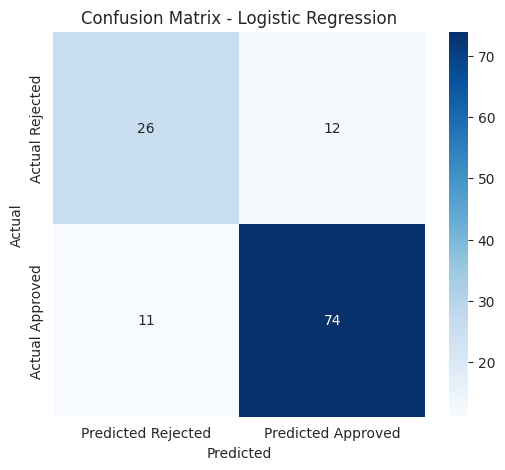

In [357]:

# 1. TRAINING THE PIPELINE ON THE ENTIRE TRAINING SET

# We already validated it via CV. Now we use ALL available training data
# to build the best possible Logistic Regression model.
pipeline_lr.fit(X_train, Y_train)


# 2. PREDICTING ON THE UNSEEN TEST SET

# The test data is untouched
Y_pred_lr = pipeline_lr.predict(X_test)


# 3. ACCURACY AND CLASSIFICATION REPORT (Precision, Recall, F1)

print("Accuracy =",accuracy_score(Y_test, Y_pred_lr))
print(classification_report(Y_test, Y_pred_lr, target_names=['Rejected (0)', 'Approved (1)']))


# 4. CONFUSION MATRIX (The "Truth Table")

cm_lr = confusion_matrix(Y_test, Y_pred_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Rejected', 'Predicted Approved'],
            yticklabels=['Actual Rejected', 'Actual Approved'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


In [358]:

# Parameter grid for Logistic Regression
param_grid_lr = {
    'model__C': [0.01, 0.1, 1.0, 10.0],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear', 'saga']  # solvers that support both l1 and l2
}

grid_lr = GridSearchCV(
    pipeline_lr,
    param_grid_lr,
    cv=cv,                    # your 5‑fold StratifiedKFold
    scoring=recall_scorer,
    n_jobs=-1,
    verbose=1
)

grid_lr.fit(X_train, Y_train)
print(f"Best LR Params: {grid_lr.best_params_}")
print(f"Best LR CV Recall: {grid_lr.best_score_:.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best LR Params: {'model__C': 10.0, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Best LR CV Recall: 0.5647



# **Summary (Logistic Regression)**
- **Best CV Recall (Tuned):** 0.5647 (Params: `C=10.0, penalty='l2', solver='liblinear'`)
- **Test Recall (Rejected):** 0.68
- **Test Precision (Rejected):** 0.70
- **Overall Test Accuracy:** 0.81

**Insights:**
- This linear model generalized best on this small structured dataset.
- L2 regularization and scaling effectively handled multicollinearity.
- It remains the most 'interpretable' model for business decisions.


# **Randomforest**

In [359]:
# 1. Defining the pipeline


pipeline_rf = ImbPipeline([
    ('scaler', StandardScaler()),                    # Step 1: Scale the data
    ('smote', SMOTE(random_state=42)),               # Step 2: Balance the classes
    ('model', RandomForestClassifier(                # Step 3: Train the model
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])

In [360]:
rf_recalls = get_cv_recall(pipeline_rf, X_train, Y_train, cv, model_name="Random Forest")

Random Forest - Avg Recall: 0.493 (+/- 0.086)


Accuracy =  0.8130081300813008
              precision    recall  f1-score   support

Rejected (0)       0.71      0.66      0.68        38
Approved (1)       0.85      0.88      0.87        85

    accuracy                           0.81       123
   macro avg       0.78      0.77      0.78       123
weighted avg       0.81      0.81      0.81       123



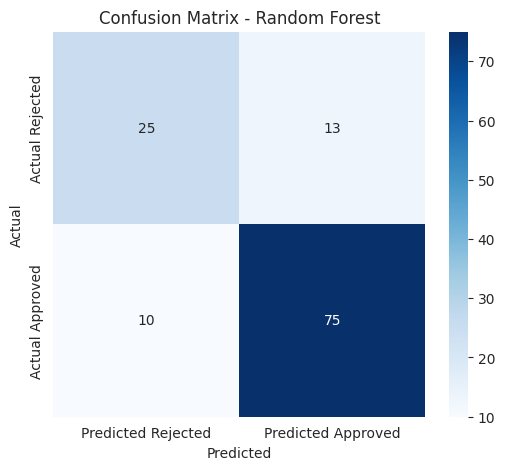

In [361]:
# 1. TRAINING THE PIPELINE ON THE ENTIRE TRAINING SET
pipeline_rf.fit(X_train, Y_train)

# 2. PREDICTING ON THE UNSEEN TEST SET
Y_pred_rf = pipeline_rf.predict(X_test)

# 3. CLASSIFICATION REPORT
print("Accuracy = ", accuracy_score(Y_test, Y_pred_rf))
print(classification_report(Y_test, Y_pred_rf, target_names=['Rejected (0)', 'Approved (1)']))

# 4. CONFUSION MATRIX
# Fixed variable name from cm_lr to cm_rf
cm_rf = confusion_matrix(Y_test, Y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Rejected', 'Predicted Approved'],
            yticklabels=['Actual Rejected', 'Actual Approved'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [362]:
param_grid_rf = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__class_weight': ['balanced', 'balanced_subsample']  # already have 'balanced', but explore both
}

grid_rf = GridSearchCV(
    pipeline_rf,
    param_grid_rf,
    cv=cv,
    scoring=recall_scorer,
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, Y_train)
print(f" Best RF Params: {grid_rf.best_params_}")
print(f" Best RF CV Recall: {grid_rf.best_score_:.4f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
 Best RF Params: {'model__class_weight': 'balanced', 'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 50}
 Best RF CV Recall: 0.5065



# **Summary (Random Forest)**
- **Avg CV Recall (Initial):** 0.493 (+/- 0.086)
- **Best CV Recall (Tuned):** 0.5065 (Params: `n_estimators=50, max_depth=None, min_samples_split=2`)
- **Test Recall (Rejected):** 0.66
- **Test Precision (Rejected):** 0.71
- **Overall Test Accuracy:** 0.81

**Insights:**
- Random Forest provided high precision but slightly lower recall for rejections compared to the other models.
- Tuning provided a marginal boost to the cross-validation performance.


# **XGBoost**

In [363]:

pipeline_xgb_calibrated = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('clf', CalibratedClassifierCV(
        XGBClassifier(
            random_state=RANDOM_STATE,
            eval_metric='logloss'
        ),
        method='sigmoid',      # 'sigmoid' (Platt) works well for small data; 'isotonic' for larger
        cv=3                   # Use 3-fold inside the calibrator to avoid overfitting
    ))
])

In [364]:
xgb_recalls = get_cv_recall(pipeline_xgb_calibrated, X_train, Y_train, cv, model_name="XGBoost")

XGBoost - Avg Recall: 0.558 (+/- 0.094)


Accuracy =  0.7642276422764228
              precision    recall  f1-score   support

Rejected (0)       0.60      0.68      0.64        38
Approved (1)       0.85      0.80      0.82        85

    accuracy                           0.76       123
   macro avg       0.73      0.74      0.73       123
weighted avg       0.77      0.76      0.77       123



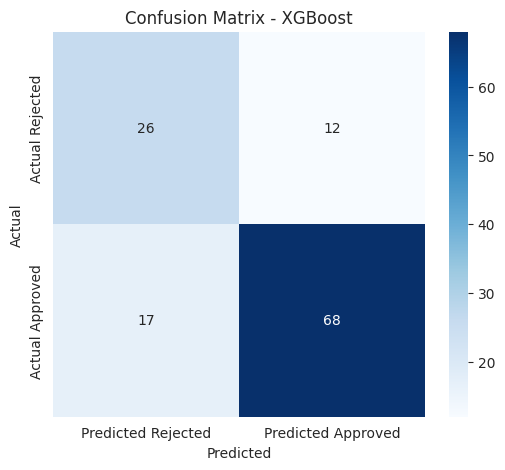

In [365]:

# 1. TRAINING THE PIPELINE ON THE ENTIRE TRAINING SET

# We already validated it via CV. Now we use ALL available training data
# to build the best possible XGBoost model.

pipeline_xgb_calibrated.fit(X_train, Y_train)


# 2. PREDICTING ON THE UNSEEN TEST SET

# The test set has been sitting untouched. This is the moment of truth.
Y_pred_lr = pipeline_xgb_calibrated.predict(X_test)


# 3. CLASSIFICATION REPORT (Precision, Recall, F1)

print("Accuracy = ", accuracy_score(Y_test, Y_pred_lr))
print(classification_report(Y_test, Y_pred_lr, target_names=['Rejected (0)', 'Approved (1)']))



# 4. CONFUSION MATRIX (The "Truth Table")

cm_lr = confusion_matrix(Y_test, Y_pred_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Rejected', 'Predicted Approved'],
            yticklabels=['Actual Rejected', 'Actual Approved'])
plt.title('Confusion Matrix - XGBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [366]:
param_grid_xgb = {
    'clf__estimator__n_estimators': [50, 100, 200],
    'clf__estimator__max_depth': [3, 5, 7],
    'clf__estimator__learning_rate': [0.01, 0.1, 0.2],
    'clf__estimator__subsample': [0.8, 1.0],
    'clf__estimator__colsample_bytree': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    pipeline_xgb_calibrated,
    param_grid_xgb,
    cv=cv,
    scoring=recall_scorer,
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train, Y_train)
print(f"Best XGB Params: {grid_xgb.best_params_}")
print(f"Best XGB CV Recall: {grid_xgb.best_score_:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best XGB Params: {'clf__estimator__colsample_bytree': 0.8, 'clf__estimator__learning_rate': 0.2, 'clf__estimator__max_depth': 5, 'clf__estimator__n_estimators': 100, 'clf__estimator__subsample': 0.8}
Best XGB CV Recall: 0.5910


In [367]:


# 1. Best model
best_xgb = grid_xgb.best_estimator_

# 2. Get cross-validated probabilities (out-of-fold predictions)
probs_cv = cross_val_predict(
    best_xgb,
    X_train, Y_train,
    cv=5,
    method='predict_proba'
)[:, 1]

# 3. Find best threshold using CV predictions
best_f1 = 0
best_th = 0.5

for th in np.arange(0.3, 0.71, 0.02):
    y_pred = (probs_cv >= th).astype(int)
    f1 = f1_score(Y_train, y_pred, pos_label=0)
    if f1 > best_f1:
        best_f1 = f1
        best_th = th

print(f"Best threshold (CV): {best_th:.2f}")
print(f"CV F1 (Rejected): {best_f1:.3f}")

# 5. Test set evaluation
probs_test = best_xgb.predict_proba(X_test)[:, 1]
y_pred_test = (probs_test >= best_th).astype(int)

print("\nFinal Results:")
print(classification_report(Y_test, y_pred_test, target_names=['Rejected (0)', 'Approved (1)']))

Best threshold (CV): 0.44
CV F1 (Rejected): 0.562

Final Results:
              precision    recall  f1-score   support

Rejected (0)       0.68      0.68      0.68        38
Approved (1)       0.86      0.86      0.86        85

    accuracy                           0.80       123
   macro avg       0.77      0.77      0.77       123
weighted avg       0.80      0.80      0.80       123




# **Summary (XGBoost)**
- **Avg CV Recall (Initial):** 0.558 (+/- 0.094)
- **Best CV Recall (Tuned):** 0.5910 (Params: `n_estimators=100, max_depth=5, learning_rate=0.2`)
- **Test Recall (Rejected, Optimized Threshold):** 0.68
- **Test Precision (Rejected):** 0.68
- **Overall Test Accuracy:** 0.80

**Insights:**
- Hyperparameter tuning and threshold optimization (Best Threshold: 0.44) significantly improved the balance between precision and recall.
- Calibration helped the model produce more reliable probability estimates for risk assessment.
